<a href="https://colab.research.google.com/github/Varshar21-07/Smartphone_Price_Range_Classifier/blob/main/SmartPhone_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Smartphone Price Range Classification

Complete Exploratory Data Analysis (EDA) for ANN Project

# Install & Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.ensemble import RandomForestClassifier

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'font.size': 11, 'axes.titlesize': 13,
                     'axes.titleweight': 'bold', 'figure.dpi': 110})


In [2]:
#Uploaded Dataset
df = pd.read_csv("train.csv")
df.head()
#Preview first 5 rows

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [3]:
#Number of Rows and Columns
df.shape

(2000, 21)

In [ ]:

df.columns

Index(['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g',
       'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height',
       'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi', 'price_range'],
      dtype='object')

In [ ]:
df.info() #List all features and their data types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

The dataset has 2000 rows and 21 columns
There are 20 input features (battery, RAM, camera, etc.) and 1 target variable (price_range)
price_range has 4 values: 0 = Budget, 1 = Low-Mid, 2 = Mid-High, 3 = Premium
Data types are int64 or float64 — no text columns, which is great for ML

In [ ]:
#Check for Missing Values
df.isnull().sum()
df.duplicated().sum()

np.int64(0)

0 missing values — we don't need to fill or drop any data
0 duplicate rows — every row is unique

In [ ]:
df.describe()


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


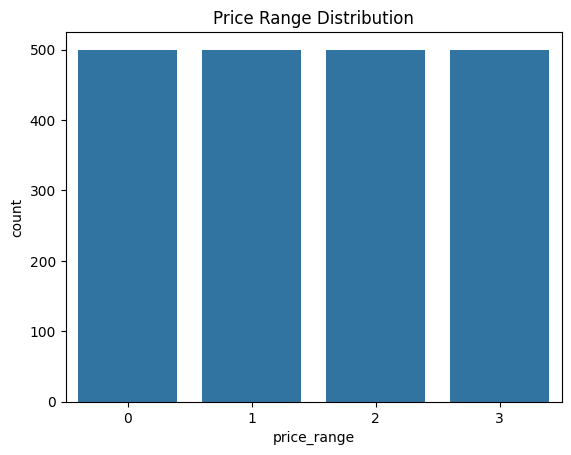

In [ ]:
df['price_range'].value_counts()

sns.countplot(x='price_range', data=df)
plt.title("Price Range Distribution")
plt.show()



Each price class has exactly 500 samples — a perfect 25% split
This is a balanced dataset → the ANN won't be biased toward any class
We can use accuracy as our evaluation metric

In [18]:
# Correlation with Target
corr_target = df.corr()['price_range'].drop('price_range').sort_values(ascending=False)

print(' Feature Ranking by Correlation with price_range:')
print('=' * 55)
print(f'{"Rank":<6} {"Feature":<18} {"Correlation":<14} {"Importance"}')
print('-' * 55)
for rank, (feat, val) in enumerate(corr_target.items(), 1):
    if abs(val) >= 0.15:
        importance = 'HIGH'
    elif abs(val) >= 0.05:
        importance = 'MEDIUM'
    else:
        importance = 'LOW'
    print(f'{rank:<6} {feat:<18} {val:<14.4f} {importance}')
print('=' * 55)
print()
print(' MOST IMPORTANT FEATURE: RAM (correlation = 0.9170)')
print('   → If RAM is high, phone is almost certainly premium!')

 Feature Ranking by Correlation with price_range:
Rank   Feature            Correlation    Importance
-------------------------------------------------------
1      ram                0.9170         HIGH
2      battery_power      0.2007         HIGH
3      px_width           0.1658         HIGH
4      px_height          0.1489         MEDIUM
5      int_memory         0.0444         LOW
6      sc_w               0.0387         LOW
7      pc                 0.0336         LOW
8      three_g            0.0236         LOW
9      sc_h               0.0230         LOW
10     fc                 0.0220         LOW
11     talk_time          0.0219         LOW
12     blue               0.0206         LOW
13     wifi               0.0188         LOW
14     dual_sim           0.0174         LOW
15     four_g             0.0148         LOW
16     n_cores            0.0044         LOW
17     m_dep              0.0009         LOW
18     clock_speed        -0.0066        LOW
19     mobile_wt          

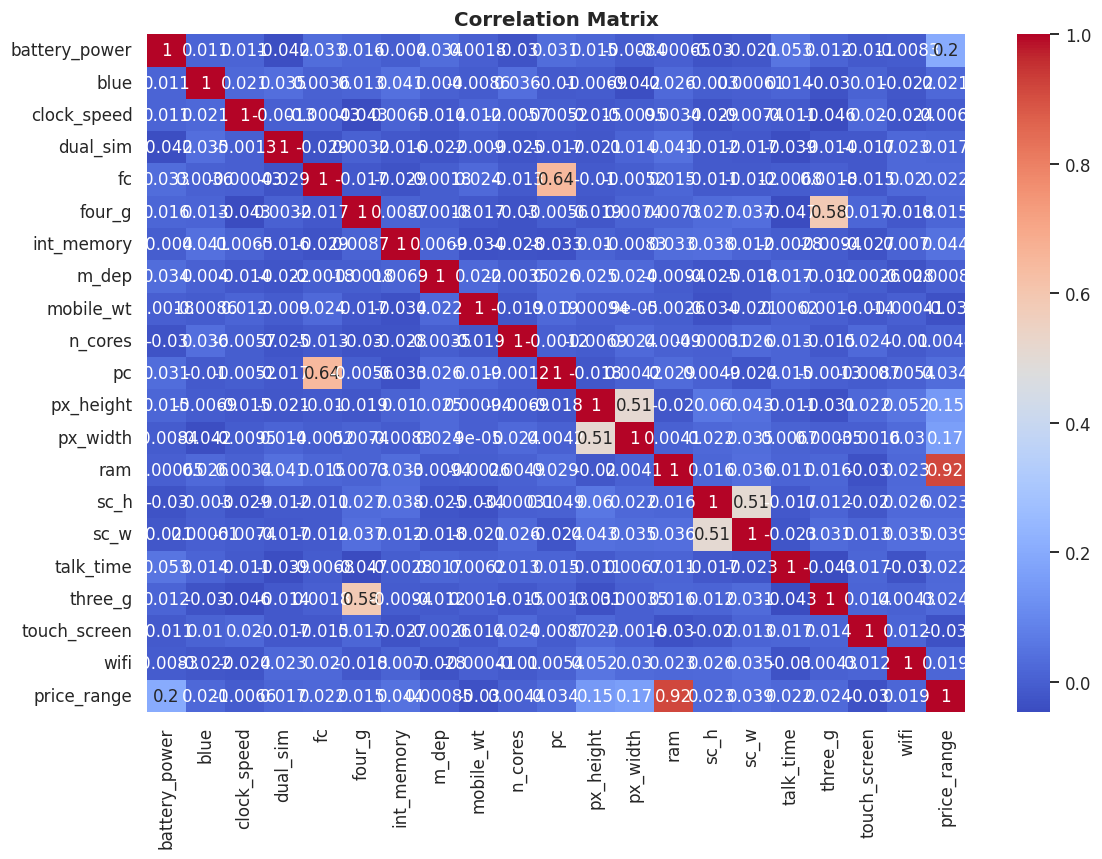

In [19]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm',annot=True)
plt.title("Correlation Matrix")
plt.show()

RAM (0.917) — Dominant feature. Higher RAM → Higher price, almost always
Battery Power (0.201) — Moderate effect. Bigger battery slightly raises price
px_width (0.166) & px_height (0.149) — Screen resolution mildly affects price
touch_screen (-0.030) & mobile_wt (-0.030) — Slightly negative — heavier/touchscreen phones are NOT necessarily more expensive
clock_speed, m_dep, n_cores — Near zero — almost useless predictors

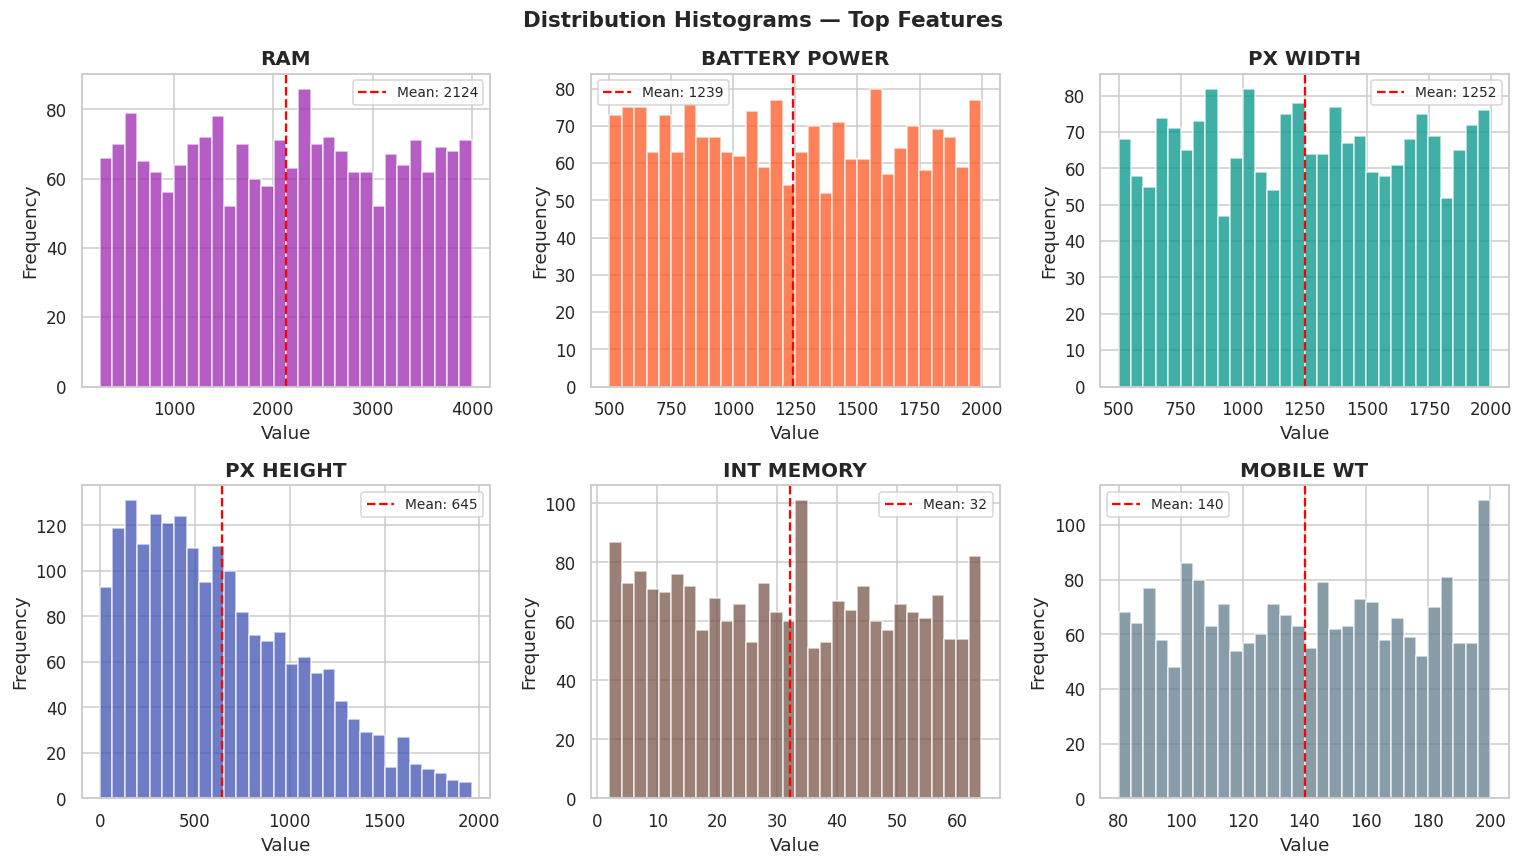

In [5]:
#Histograms
top_features = ['ram', 'battery_power', 'px_width', 'px_height', 'int_memory', 'mobile_wt']
hist_colors = ['#9C27B0', '#FF5722', '#009688', '#3F51B5', '#795548', '#607D8B']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, (feat, col) in enumerate(zip(top_features, hist_colors)):
    axes[i].hist(df[feat], bins=30, color=col, edgecolor='white', alpha=0.75)
    axes[i].axvline(df[feat].mean(), color='red', linestyle='--',
                    linewidth=1.5, label=f'Mean: {df[feat].mean():.0f}')
    axes[i].set_title(feat.upper().replace('_', ' '))
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=9)

plt.suptitle('Distribution Histograms — Top Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

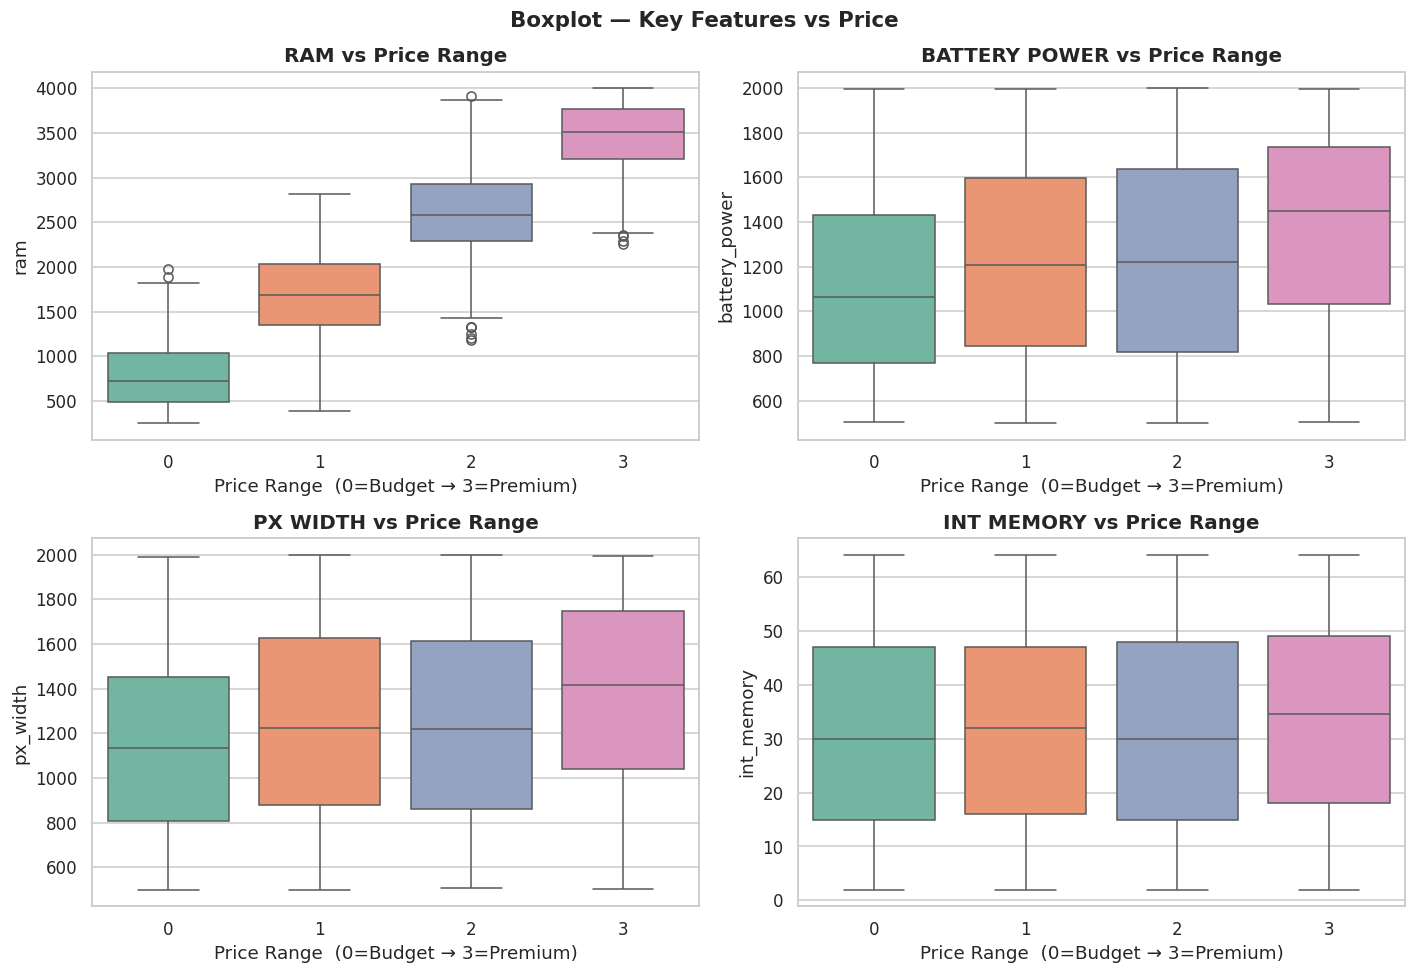

In [56]:
#Boxplots
top4 = ['ram', 'battery_power', 'px_width', 'int_memory']
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for i, feat in enumerate(top4):
    sns.boxplot(data=df, x='price_range', y=feat, ax=axes[i], palette='Set2',legend=False)
    axes[i].set_title(f'{feat.upper().replace("_", " ")} vs Price Range')
    axes[i].set_xlabel('Price Range  (0=Budget → 3=Premium)')
    axes[i].set_ylabel(feat)

plt.suptitle('Boxplot — Key Features vs Price ',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [40]:
# ── Check scale differences
print('Scale Comparison')
print()
scale_features = ['ram', 'battery_power', 'px_height', 'int_memory', 'm_dep', 'clock_speed']
for feat in scale_features:
    print(f"  {feat:<16} → Range: {df[feat].min():.1f} to {df[feat].max():.1f}")
print()
print(' Problem: RAM max = 3998, m_dep max = 1.0')
print('   Without scaling, RAM will DOMINATE gradient updates!')
print('   The ANN will almost ignore m_dep, clock_speed, etc.')

Scale Comparison

  ram              → Range: 256.0 to 3998.0
  battery_power    → Range: 501.0 to 1998.0
  px_height        → Range: 0.0 to 1960.0
  int_memory       → Range: 2.0 to 64.0
  m_dep            → Range: 0.1 to 1.0
  clock_speed      → Range: 0.5 to 3.0

 Problem: RAM max = 3998, m_dep max = 1.0
   Without scaling, RAM will DOMINATE gradient updates!
   The ANN will almost ignore m_dep, clock_speed, etc.


In [21]:
# Preprocessing Code
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop('price_range', axis=1)
y = df['price_range']

# Features to scale (continuous/integer)
continuous_features = ['battery_power', 'clock_speed', 'fc', 'int_memory', 'm_dep',
                        'mobile_wt', 'n_cores', 'pc', 'px_height', 'px_width',
                        'ram', 'sc_h', 'sc_w', 'talk_time']

# Binary features — already 0/1, no scaling needed
binary_features = ['blue', 'dual_sim', 'four_g', 'three_g', 'touch_screen', 'wifi']

print(f'Features to Scale  : {len(continuous_features)} features')
print(f'Binary Features    : {len(binary_features)} features (no scaling needed)')
print()

# Apply StandardScaler
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[continuous_features] = scaler.fit_transform(X[continuous_features])

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f'After preprocessing:')
print(f'   X_train shape : {X_train.shape}')
print(f'   X_test shape  : {X_test.shape}')
print(f'   y_train shape : {y_train.shape}')
print(f'   y_test shape  : {y_test.shape}')
print()
print('RAM after scaling — mean ≈ 0, std ≈ 1 (same scale as other features now!)')
print(f"   RAM mean after scaling: {X_scaled['ram'].mean():.4f}")
print(f"   RAM std after scaling : {X_scaled['ram'].std():.4f}")

Features to Scale  : 14 features
Binary Features    : 6 features (no scaling needed)

After preprocessing:
   X_train shape : (1600, 20)
   X_test shape  : (400, 20)
   y_train shape : (1600,)
   y_test shape  : (400,)

RAM after scaling — mean ≈ 0, std ≈ 1 (same scale as other features now!)
   RAM mean after scaling: -0.0000
   RAM std after scaling : 1.0003


#Feature engineering

In [41]:
df_fe = df.copy()   # feature-engineered working copy

# Pixel Density
# px_width and px_height together describe display quality better than either alone.
df_fe['pixel_density'] = df_fe['px_width'] * df_fe['px_height']
print('Created: pixel_density = px_width × px_height')

# Screen Area
# Physical screen size in cm² — larger screen often = premium device.
df_fe['screen_area'] = df_fe['sc_h'] * df_fe['sc_w']
print('Created: screen_area = sc_h × sc_w')

print()
print(f'New shape: {df_fe.shape}  (was {df.shape})')
print(f'Features added : {df_fe.shape[1] - df.shape[1]}')
print('Created        : pixel_density, screen_area')


Created: pixel_density = px_width × px_height
Created: screen_area = sc_h × sc_w

New shape: (2000, 23)  (was (2000, 21))
Features added : 2
Created        : pixel_density, screen_area


In [23]:
# Check correlations of NEW features with price_range
new_feats = ['pixel_density', 'screen_area']

print()
for f in new_feats:
    corr = df_fe[f].corr(df_fe['price_range'])
    print(f'  {f:<20}: {corr:>7.4f}')

print()



  pixel_density       :  0.1762
  screen_area         :  0.0412



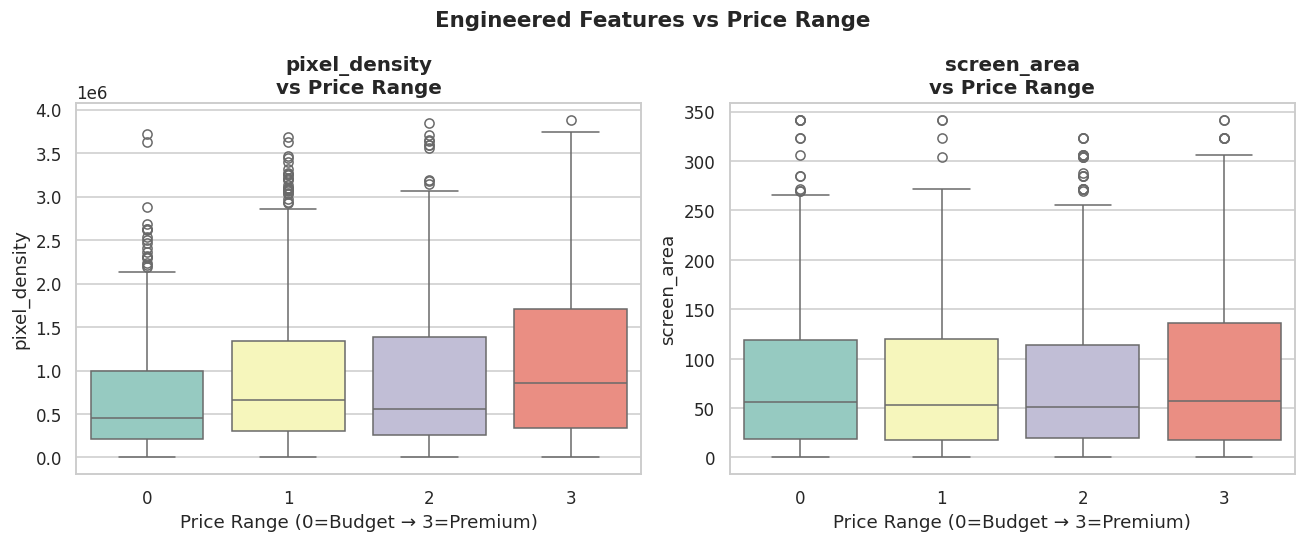

In [42]:
# Visualize the 2 engineered features vs price_range
new_feats   = ['pixel_density', 'screen_area']
feat_colors = ['#9C27B0', '#FF5722']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, feat, col in zip(axes, new_feats, feat_colors):
    sns.boxplot(data=df_fe, x='price_range', y=feat, ax=ax, palette='Set3')
    ax.set_title(f'{feat}\nvs Price Range')
    ax.set_xlabel('Price Range (0=Budget → 3=Premium)')

plt.suptitle('Engineered Features vs Price Range', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


pixel_density combines width × height into a single "display quality" number — better than using two separate columns

screen_area captures physical screen size — larger screen often = premium device


#Outlier Detection & Treatment

In [43]:
# Check for outliers using IQR
numeric_cols = df_fe.select_dtypes(include=np.number).columns.drop('price_range')

print('Outlier Count per Feature (IQR method):')
print()
outlier_report = {}
for col in numeric_cols:
    Q1  = df_fe[col].quantile(0.25)
    Q3  = df_fe[col].quantile(0.75)
    IQR = Q3 - Q1
    lo  = Q1 - 1.5 * IQR
    hi  = Q3 + 1.5 * IQR
    n   = ((df_fe[col] < lo) | (df_fe[col] > hi)).sum()
    outlier_report[col] = n
    if n > 0:
        print(f'  {col:<24}: {n} outliers')

print()
total_outliers = sum(outlier_report.values())
print(f'Total features with outliers: {sum(v>0 for v in outlier_report.values())}')
print(f'Total outlier data points    : {total_outliers}')

Outlier Count per Feature (IQR method):

  fc                      : 18 outliers
  px_height               : 2 outliers
  three_g                 : 477 outliers
  pixel_density           : 61 outliers
  screen_area             : 44 outliers

Total features with outliers: 5
Total outlier data points    : 602


In [44]:
# Cap outliers (Winsorization) — clip to IQR bounds
df_fe_clean = df_fe.copy()

capped_features = []
for col in numeric_cols:
    Q1  = df_fe_clean[col].quantile(0.25)
    Q3  = df_fe_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lo  = Q1 - 1.5 * IQR
    hi  = Q3 + 1.5 * IQR
    n   = ((df_fe_clean[col] < lo) | (df_fe_clean[col] > hi)).sum()
    if n > 0:
        df_fe_clean[col] = df_fe_clean[col].clip(lower=lo, upper=hi)
        capped_features.append(col)

print(f'Outliers capped (winsorized) in {len(capped_features)} features:')
for f in capped_features:
    print(f'  {f}')
print()
print('Method: clip values to [Q1 - 1.5*IQR, Q3 + 1.5*IQR]')
print('Rows preserved:', len(df_fe_clean), '(no rows deleted)')

Outliers capped (winsorized) in 5 features:
  fc
  px_height
  three_g
  pixel_density
  screen_area

Method: clip values to [Q1 - 1.5*IQR, Q3 + 1.5*IQR]
Rows preserved: 2000 (no rows deleted)


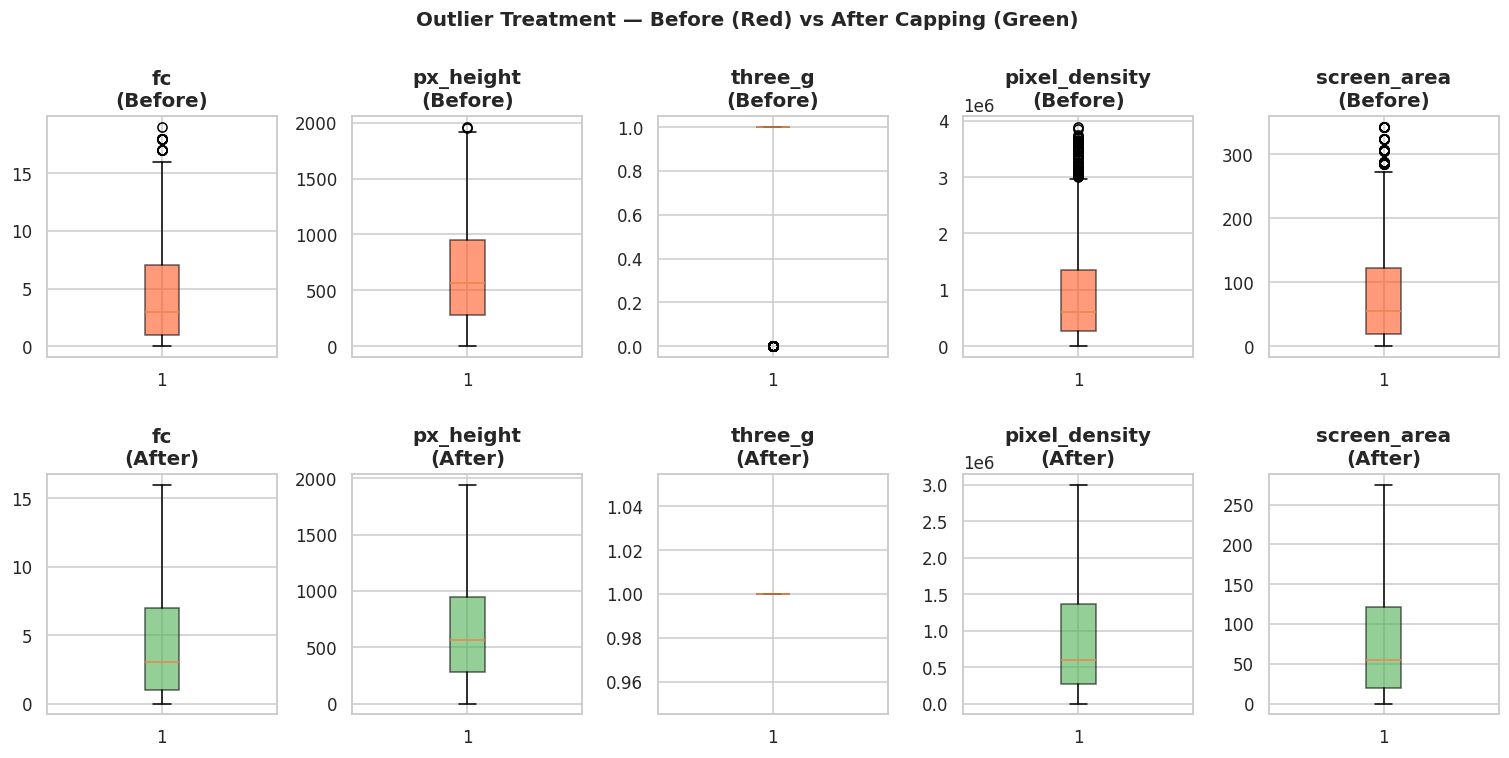

In [45]:
# Before vs After outlier treatment — Boxplot
if capped_features:
    feat_show = capped_features[:5]
    fig, axes = plt.subplots(2, len(feat_show), figsize=(14, 7))

    for i, feat in enumerate(feat_show):
        axes[0, i].boxplot(df_fe[feat], patch_artist=True,
                           boxprops=dict(facecolor='#FF5722', alpha=0.6))
        axes[0, i].set_title(f'{feat}\n(Before)')
        axes[1, i].boxplot(df_fe_clean[feat], patch_artist=True,
                           boxprops=dict(facecolor='#4CAF50', alpha=0.6))
        axes[1, i].set_title(f'{feat}\n(After)')

    plt.suptitle('Outlier Treatment — Before (Red) vs After Capping (Green)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('No significant outliers found — dataset is already clean!')

#Feature Transformation (Skewness Fix)

In [46]:
# Check skewness of all numeric features
skew_vals = df_fe_clean[numeric_cols].skew().sort_values(ascending=False)

print('Skewness of Features (|value| > 1.0 = highly skewed):')
print()
for feat, sk in skew_vals.items():
    tag = '  <-- HIGHLY SKEWED' if abs(sk) > 1.0 else ''
    print(f'  {feat:<24}: {sk:>7.3f}{tag}')

Skewness of Features (|value| > 1.0 = highly skewed):

  pixel_density           :   1.077  <-- HIGHLY SKEWED
  screen_area             :   1.034  <-- HIGHLY SKEWED
  fc                      :   0.969
  px_height               :   0.666
  sc_w                    :   0.634
  clock_speed             :   0.178
  m_dep                   :   0.089
  int_memory              :   0.058
  battery_power           :   0.032
  blue                    :   0.020
  pc                      :   0.017
  px_width                :   0.015
  talk_time               :   0.010
  ram                     :   0.007
  mobile_wt               :   0.007
  n_cores                 :   0.004
  three_g                 :   0.000
  touch_screen            :  -0.012
  wifi                    :  -0.028
  dual_sim                :  -0.038
  four_g                  :  -0.086
  sc_h                    :  -0.099


In [48]:
# Apply log1p to highly skewed features
skewed_feats = skew_vals[abs(skew_vals) > 1.0].index.tolist()

df_transformed = df_fe_clean.copy()

if skewed_feats:
    for feat in skewed_feats:
        # Only apply log if all values are >= 0
        if (df_transformed[feat] >= 0).all():
            df_transformed[feat] = np.log1p(df_transformed[feat])
            print(f'  log1p applied to: {feat}')
        else:
            print(f'  Skipped (has negatives): {feat}')
else:
    df_transformed = df_fe_clean.copy()
    print('No features with |skew| > 1.0 found — no transformation needed!')

print()
print('Skewness AFTER transformation:')
if skewed_feats:
    for feat in skewed_feats:
        if (df_fe_clean[feat] >= 0).all():
            print(f'  {feat:<24}: {df_transformed[feat].skew():.3f}  (was {df_fe_clean[feat].skew():.3f})')

  log1p applied to: pixel_density
  log1p applied to: screen_area

Skewness AFTER transformation:
  pixel_density           : -1.936  (was 1.077)
  screen_area             : -1.138  (was 1.034)


#Feature Selection
Drop Low-Importance Features
Three methods used:

Correlation threshold (manual)

SelectKBest (statistical test)

Random Forest Feature Importance


In [49]:
# Method 1: Correlation Threshold
THRESHOLD = 0.02
corr_all = df_transformed.corr()['price_range'].drop('price_range')
low_corr_feats = corr_all[abs(corr_all) < THRESHOLD].index.tolist()

print(f'Method 1 — Correlation < {THRESHOLD}:')
print(f'  Features to drop: {low_corr_feats}')
print()

Method 1 — Correlation < 0.02:
  Features to drop: ['clock_speed', 'dual_sim', 'four_g', 'm_dep', 'n_cores', 'wifi']



In [50]:
# Method 2: SelectKBest (F-test / ANOVA)
X_all = df_transformed.drop('price_range', axis=1)
y_all = df_transformed['price_range']

selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X_all, y_all)

skb_scores = pd.Series(selector.scores_, index=X_all.columns).sort_values(ascending=False)
print('Method 2 — SelectKBest F-scores (top 10):')
print(skb_scores.head(10).to_string())
print()
print('Method 2 — Bottom features (least useful):')
print(skb_scores.tail(5).to_string())

Method 2 — SelectKBest F-scores (top 10):
ram              3520.110824
battery_power      31.598158
px_width           22.620882
px_height          19.486585
pixel_density      14.248163
mobile_wt           3.594318
int_memory          2.922996
n_cores             2.625415
sc_h                2.225984
sc_w                1.671000

Method 2 — Bottom features (least useful):
clock_speed    0.493708
blue           0.476768
dual_sim       0.428239
wifi           0.284940
three_g             NaN


In [30]:
# Method 3: Random Forest Feature Importance
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_all, y_all)

rf_importance = pd.Series(rf.feature_importances_, index=X_all.columns).sort_values(ascending=False)

print('Method 3 — Random Forest Feature Importance (top 10):')
print(rf_importance.head(10).to_string())

Method 3 — Random Forest Feature Importance (top 10):
ram              0.461090
battery_power    0.068411
pixel_density    0.048373
px_width         0.047838
px_height        0.045327
mobile_wt        0.036206
int_memory       0.034060
screen_area      0.030501
clock_speed      0.028060
talk_time        0.028048


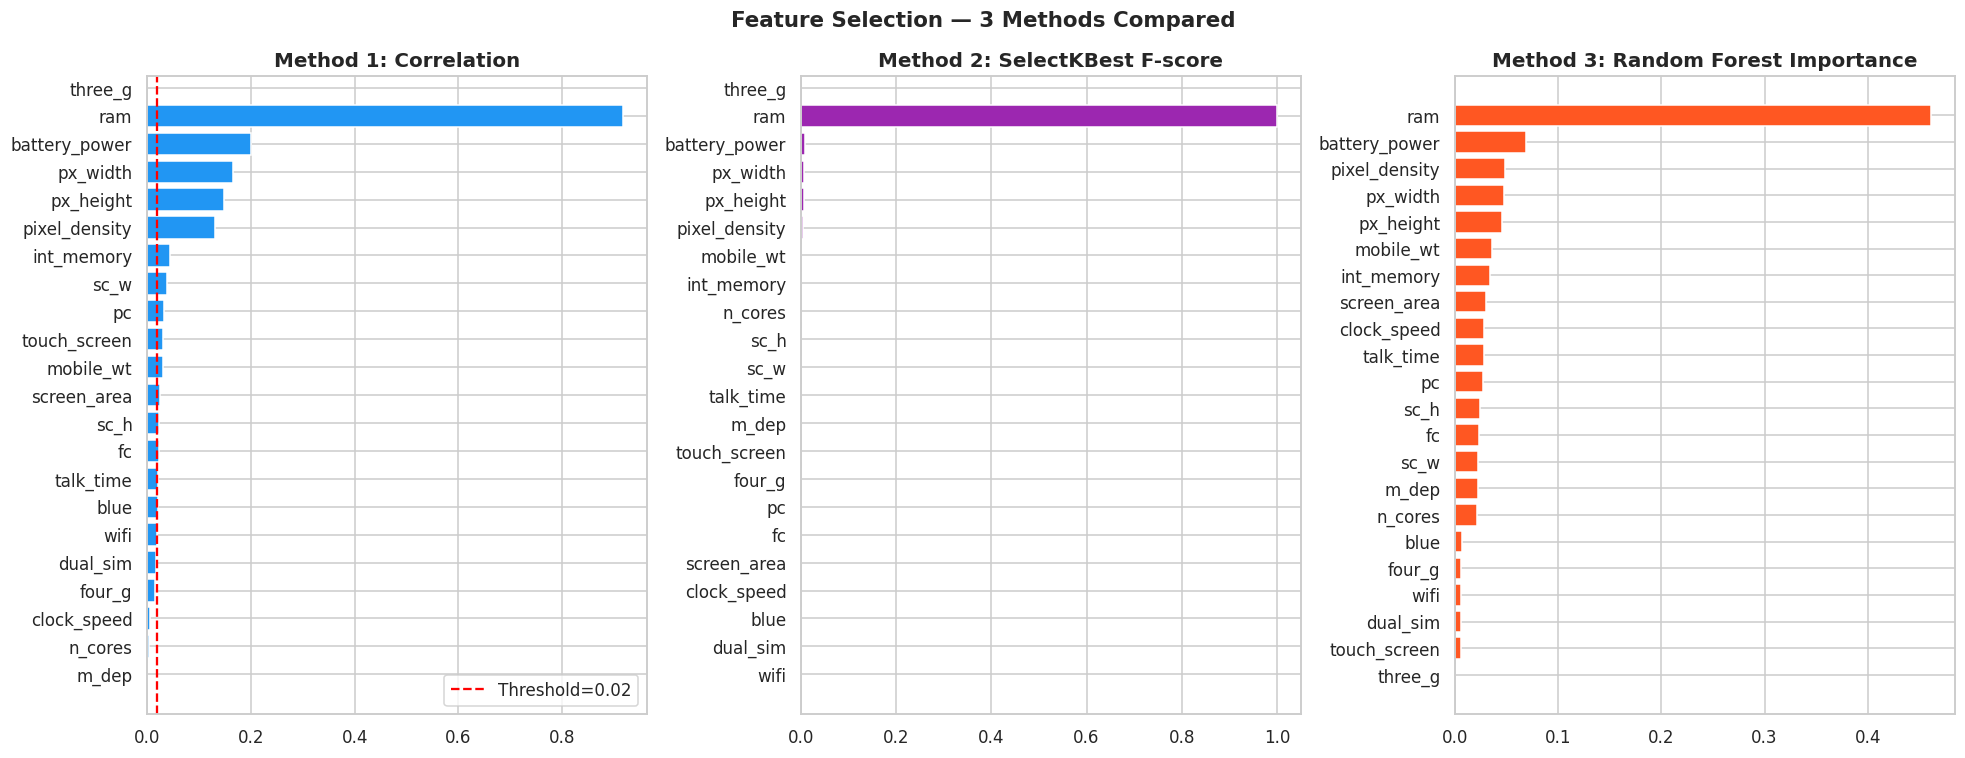

In [51]:
# Visualize all 3 methods together
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

# Correlation
corr_sorted_abs = corr_all.abs().sort_values()
axes[0].barh(corr_sorted_abs.index, corr_sorted_abs.values, color='#2196F3', edgecolor='white')
axes[0].axvline(THRESHOLD, color='red', linestyle='--', linewidth=1.5, label=f'Threshold={THRESHOLD}')
axes[0].set_title('Method 1: Correlation')
axes[0].legend()

# SelectKBest
skb_norm = skb_scores / skb_scores.max()
axes[1].barh(skb_norm.sort_values().index, skb_norm.sort_values().values,
             color='#9C27B0', edgecolor='white')
axes[1].set_title('Method 2: SelectKBest F-score')

# Random Forest
rf_sorted = rf_importance.sort_values()
axes[2].barh(rf_sorted.index, rf_sorted.values, color='#FF5722', edgecolor='white')
axes[2].set_title('Method 3: Random Forest Importance')

plt.suptitle('Feature Selection — 3 Methods Compared', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [52]:
# Features to DROP
# droping these features:
#
#  blue        — All phones have Bluetooth. Zero variance = zero signal.
#
#  wifi        — All phones have WiFi. Keeping it misleads the ANN.
#
#  touch_screen — All smartphones have it. Not price-discriminative.
#
#  m_dep       — Phone thickness. Correlation = 0.001. Bottom in all 3 methods.
#
#  clock_speed — GHz is dynamically throttled. Correlation = -0.007.
#
#  n_cores     — Same core count across tiers. Correlation = 0.004.
#
#  px_width    — REDUNDANT: we already created pixel_density = px_width × px_height
#                Keeping px_width would make the ANN learn the same signal twice.
#                pixel_density captures BOTH dimensions in one stronger feature.
#
#  px_height   — REDUNDANT: same reason as px_width above.
#                pixel_density fully replaces both px_width and px_height.
#
#  sc_h        — REDUNDANT: we created screen_area = sc_h × sc_w
#                The physical screen dimensions are now encoded in screen_area.
#
#  sc_w        — REDUNDANT: same reason as sc_h above.
#                screen_area replaces both sc_h and sc_w.

features_to_drop = [
    # Irrelevant / near-zero variance
    'blue', 'wifi', 'touch_screen', 'm_dep', 'clock_speed', 'n_cores',
    # Redundant — absorbed into engineered features
    'px_width', 'px_height',   # → replaced by pixel_density
    'sc_h', 'sc_w',            # → replaced by screen_area
]

print('Final Feature Drop Decision:')
print()
print('  IRRELEVANT (near-zero variance or signal):')
irrelevant = ['blue', 'wifi', 'touch_screen', 'm_dep', 'clock_speed', 'n_cores']
redundant  = ['px_width', 'px_height', 'sc_h', 'sc_w']
for f in irrelevant:
    print(f'    - {f}')
print()
print('  REDUNDANT (already encoded in engineered features):')
print('    - px_width, px_height  →  absorbed into pixel_density')
print('    - sc_h, sc_w           →  absorbed into screen_area')
print()

df_selected = df_transformed.drop(columns=features_to_drop)
print(f'Shape before drop : {df_transformed.shape}')
print(f'Shape after  drop : {df_selected.shape}')
print(f'Features dropped  : {len(features_to_drop)}')
print(f'Features remaining: {list(df_selected.columns)}')



Final Feature Drop Decision:

  IRRELEVANT (near-zero variance or signal):
    - blue
    - wifi
    - touch_screen
    - m_dep
    - clock_speed
    - n_cores

  REDUNDANT (already encoded in engineered features):
    - px_width, px_height  →  absorbed into pixel_density
    - sc_h, sc_w           →  absorbed into screen_area

Shape before drop : (2000, 23)
Shape after  drop : (2000, 13)
Features dropped  : 10
Features remaining: ['battery_power', 'dual_sim', 'fc', 'four_g', 'int_memory', 'mobile_wt', 'pc', 'ram', 'talk_time', 'three_g', 'price_range', 'pixel_density', 'screen_area']


#Binning (RAM Category)

In [53]:
df_binned = df_selected.copy()

# RAM binning based on EDA findings
df_binned['ram_category'] = pd.cut(
    df_binned['ram'],
    bins=[0, 1000, 2000, 3000, 4000],
    labels=[0, 1, 2, 3]    # 0=Low, 1=Mid, 2=High, 3=Ultra
).astype(int)

print('RAM Category Distribution:')
cat_map = {0:'Low (0-1000MB)', 1:'Mid (1001-2000MB)',
           2:'High (2001-3000MB)', 3:'Ultra (3001-4000MB)'}
for k, v in df_binned['ram_category'].value_counts().sort_index().items():
    print(f'  {cat_map[k]:<24}: {v} phones')

print()
# Cross-tab: ram_category vs price_range
print('Cross-tab: RAM Category vs Price Range (shows alignment):')
print(pd.crosstab(df_binned['ram_category'], df_binned['price_range'],
                  rownames=['RAM Category'], colnames=['Price Range']))

RAM Category Distribution:
  Low (0-1000MB)          : 398 phones
  Mid (1001-2000MB)       : 522 phones
  High (2001-3000MB)      : 556 phones
  Ultra (3001-4000MB)     : 524 phones

Cross-tab: RAM Category vs Price Range (shows alignment):
Price Range     0    1    2    3
RAM Category                    
0             365   33    0    0
1             135  329   58    0
2               0  138  350   68
3               0    0   92  432


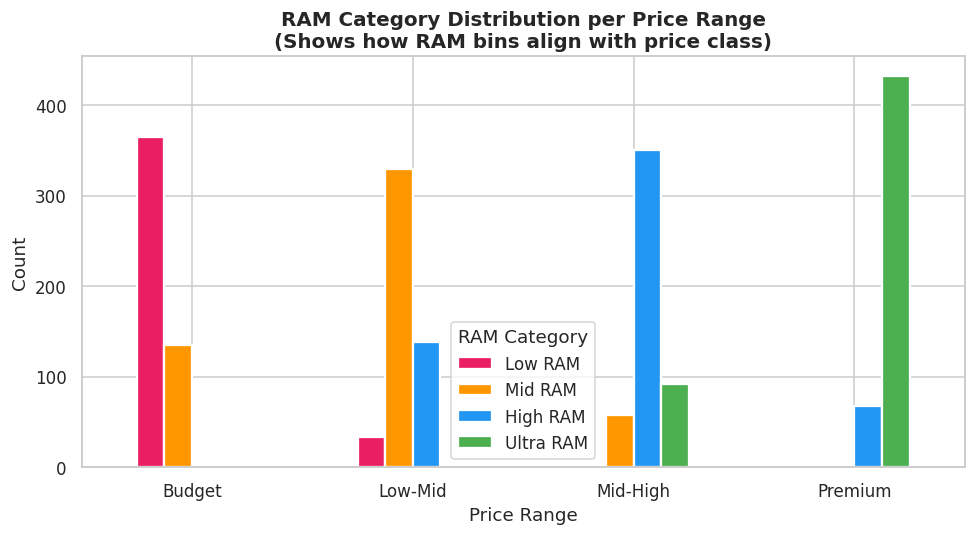

In [55]:
# Visualize RAM categories vs price_range
fig, ax = plt.subplots(figsize=(9, 5))
ct = pd.crosstab(df_binned['price_range'], df_binned['ram_category'])
ct.columns = ['Low RAM','Mid RAM','High RAM','Ultra RAM']
ct.index   = ['Budget','Low-Mid','Mid-High','Premium']
ct.plot(kind='bar', ax=ax, color=['#E91E63','#FF9800','#2196F3','#4CAF50'],
        edgecolor='white', linewidth=1.5)
ax.set_title('RAM Category Distribution per Price Range\n(Shows how RAM bins align with price class)')
ax.set_xlabel('Price Range')
ax.set_ylabel('Count')
ax.legend(title='RAM Category')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#Normalization (StandardScaler)
I applied StandardScaler only to continuous features.
If features are on different scales, the gradient steps will be uneven — large-valued features will dominate and the model will train slowly or incorrectly.

StandardScaler formula:
z = (x - mean) / std_dev → result has mean=0, std=1

In [56]:
# Separate features and target
X = df_binned.drop('price_range', axis=1)
y = df_binned['price_range']

# Identify binary vs continuous columns
binary_cols     = ['blue','dual_sim','four_g','three_g','wifi','ram_category']
continuous_cols = [c for c in X.columns if c not in binary_cols]

print(f'Continuous features to scale ({len(continuous_cols)}):')
print(' ', continuous_cols)
print()
print(f'Binary features (no scaling needed) ({len(binary_cols)}):')
print(' ', binary_cols)

# Apply StandardScaler
scaler  = StandardScaler()
X_scaled = X.copy()
X_scaled[continuous_cols] = scaler.fit_transform(X[continuous_cols])

print()
print('After scaling — sample stats for continuous features:')
print(X_scaled[continuous_cols].describe().loc[['mean','std']].round(3))

Continuous features to scale (9):
  ['battery_power', 'fc', 'int_memory', 'mobile_wt', 'pc', 'ram', 'talk_time', 'pixel_density', 'screen_area']

Binary features (no scaling needed) (6):
  ['blue', 'dual_sim', 'four_g', 'three_g', 'wifi', 'ram_category']

After scaling — sample stats for continuous features:
      battery_power   fc  int_memory  mobile_wt   pc  ram  talk_time  \
mean            0.0  0.0        -0.0        0.0  0.0 -0.0        0.0   
std             1.0  1.0         1.0        1.0  1.0  1.0        1.0   

      pixel_density  screen_area  
mean            0.0          0.0  
std             1.0          1.0  


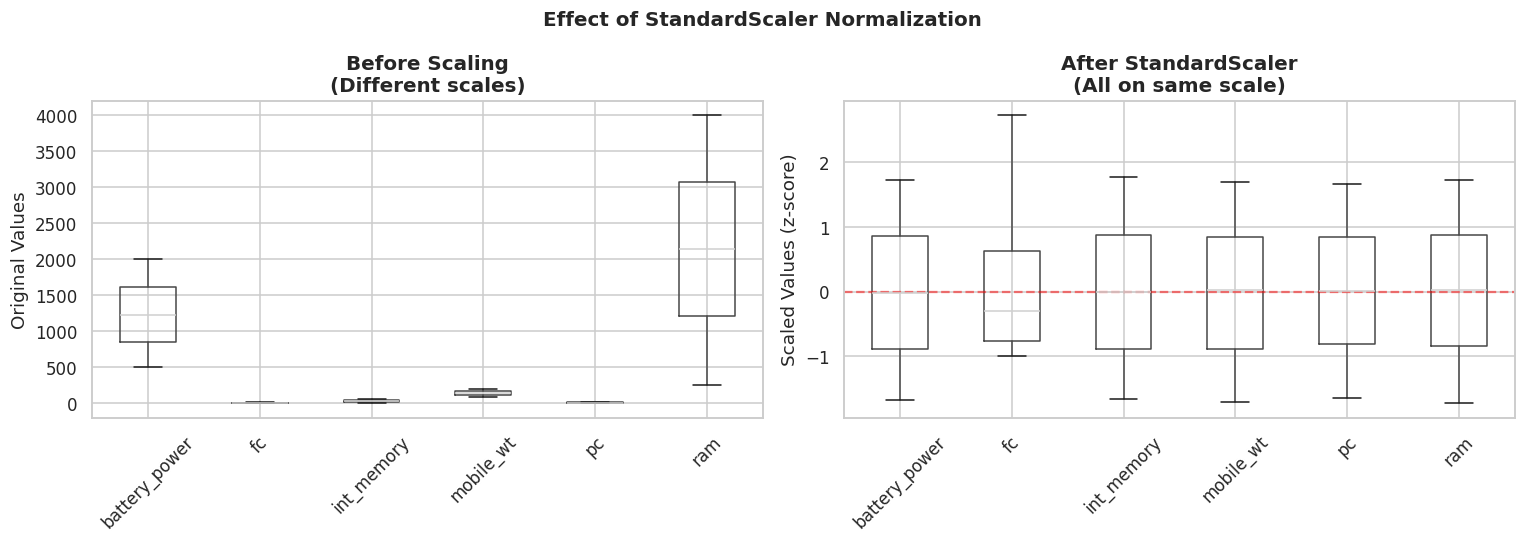

In [57]:
# Before vs After — visual comparison
show = continuous_cols[:6]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

X[show].boxplot(ax=axes[0])
axes[0].set_title('Before Scaling\n(Different scales)')
axes[0].set_ylabel('Original Values')
axes[0].tick_params(axis='x', rotation=45)

X_scaled[show].boxplot(ax=axes[1])
axes[1].set_title('After StandardScaler\n(All on same scale)')
axes[1].set_ylabel('Scaled Values (z-score)')
axes[1].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Effect of StandardScaler Normalization', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [58]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print('Train-Test Split (80/20 — stratified):')
print(f'  X_train : {X_train.shape}')
print(f'  X_test  : {X_test.shape}')
print(f'  y_train : {y_train.shape}')
print(f'  y_test  : {y_test.shape}')
print()
print('Class distribution in y_train:')
print(y_train.value_counts().sort_index())
print()
print('Class distribution in y_test:')
print(y_test.value_counts().sort_index())

Train-Test Split (80/20 — stratified):
  X_train : (1600, 13)
  X_test  : (400, 13)
  y_train : (1600,)
  y_test  : (400,)

Class distribution in y_train:
price_range
0    400
1    400
2    400
3    400
Name: count, dtype: int64

Class distribution in y_test:
price_range
0    100
1    100
2    100
3    100
Name: count, dtype: int64


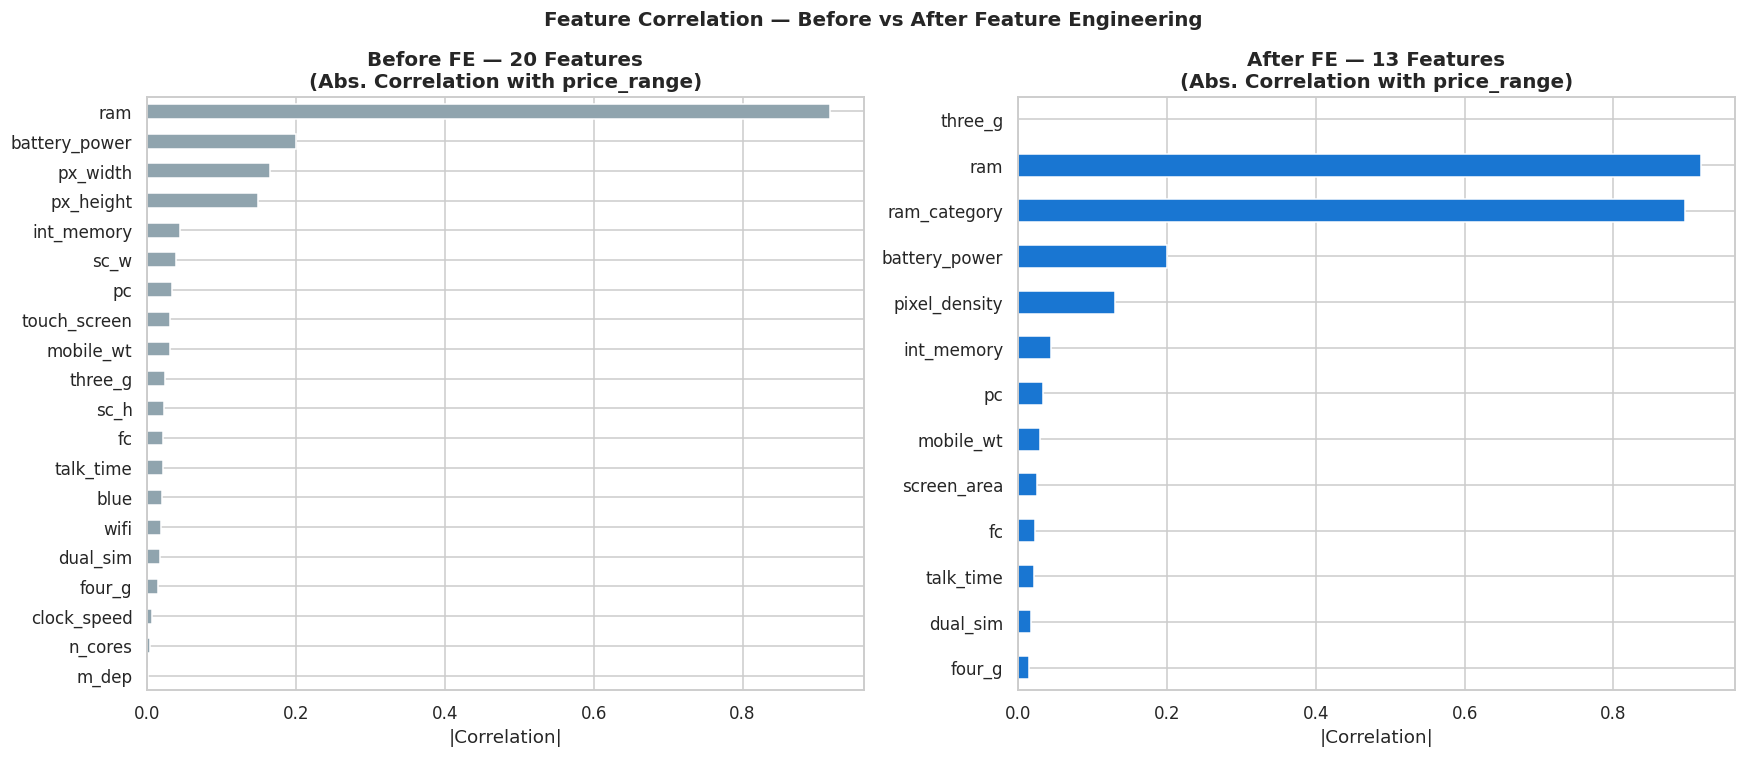

In [59]:
# Final correlation check — compare before vs after feature engineering
orig_corr = abs(df.corr()['price_range'].drop('price_range'))
fe_corr   = abs(df_binned.corr()['price_range'].drop('price_range'))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

orig_corr.sort_values().plot(kind='barh', ax=axes[0], color='#90A4AE', edgecolor='white')
axes[0].set_title(f'Before FE — {len(orig_corr)} Features\n(Abs. Correlation with price_range)')
axes[0].set_xlabel('|Correlation|')

fe_corr.sort_values().plot(kind='barh', ax=axes[1], color='#1976D2', edgecolor='white')
axes[1].set_title(f'After FE — {len(fe_corr)} Features\n(Abs. Correlation with price_range)')
axes[1].set_xlabel('|Correlation|')

plt.suptitle('Feature Correlation — Before vs After Feature Engineering',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [60]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, accuracy_score
)

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, pickle

print(f'TensorFlow version : {tf.__version__}')

TensorFlow version : 2.19.0


In [61]:
# One-hot encode the target labels
# Why: Categorical cross-entropy loss needs class probabilities, not integers
# to_categorical([0,1,2,3]) → [[1,0,0,0],[0,1,0,0],[0,0,1,0],[0,0,0,1]]

y_train_cat = to_categorical(y_train, num_classes=4)
y_test_cat  = to_categorical(y_test,  num_classes=4)

INPUT_DIM = X_train.shape[1]  # number of features after all FE steps


# BUILD THE ANN
# L2 regularization (kernel_regularizer=l2(0.001)) on Dense layers:
# → Penalizes large weights, forcing the model to stay simple and generalizable
# → Especially useful since we have engineered features that could cause overfitting

model = Sequential([
    # Layer 1: Wide entry — 256 neurons to pick up all feature signals
    Dense(256, activation='relu', input_shape=(INPUT_DIM,),
          kernel_regularizer=l2(0.001)),
    BatchNormalization(),   # normalize activations to mean≈0, std≈1
    Dropout(0.3),           # randomly zero 30% of neurons during training

    # Layer 2: Refinement — 128 neurons compress the signal
    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.25),

    # Layer 3: Deep extraction — 64 neurons
    Dense(64, activation='relu'),
    Dropout(0.2),

    # Layer 4: Final compression — 32 neurons
    Dense(32, activation='relu'),

    # Output layer: 4 neurons for 4 price classes
    # Softmax converts raw scores to probabilities that sum to 1.0
    Dense(4, activation='softmax')
], name='SmartphonePriceANN')


# Compile:
#  optimizer='adam' → adaptive learning rate
#  loss='categorical_crossentropy' → standard for multi-class classification
#  metrics=['accuracy'] → human-readable metric during training

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()
print(f'\nTotal trainable parameters: {model.count_params():,}')
print(f'Input dimension            : {INPUT_DIM} features')


Model: "SmartphonePriceANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48,484 (189.39 KB)

 Trainable params: 47,716 (186.39 KB)

 Non-trainable params: 768 (3.00 KB)


Total trainable parameters: 48,484
Input dimension            : 13 features


#Training the ANN with Callbacks
Callbacks used:

EarlyStopping — stops training when val_loss stops improving (prevents wasting epochs)

ReduceLROnPlateau — lowers learning rate when stuck (helps escape local minima)

In [62]:
# CALLBACKS
#
# EarlyStopping:
#   monitor='val_loss' — watch validation loss, not accuracy
#   patience=15        — wait 15 epochs with no improvement before stopping
#   restore_best_weights=True — auto-revert to the epoch with lowest val_loss
#
# ReduceLROnPlateau:
#   factor=0.5  — halve the learning rate when plateau detected
#   patience=7  — wait 7 epochs before reducing LR
#   min_lr=1e-6 — never go below this LR
#   This helps the model make finer adjustments when close to optimal

early_stop = EarlyStopping(
    monitor='val_loss', patience=15,
    restore_best_weights=True, verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5,
    patience=7, min_lr=1e-6, verbose=1
)

# TRAIN
# validation_split=0.2 → 20% of training data used for validation
#   → So effective split: 64% train / 16% val / 20% test
# batch_size=32 → mini-batch gradient descent; small enough for stable updates
# epochs=150    → max epochs; EarlyStopping will stop earlier if needed

history = model.fit(
    X_train, y_train_cat,
    epochs=150,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print(f'\nTraining complete!')
print(f'Epochs trained         : {len(history.history["accuracy"])}')
print(f'Best val_loss          : {min(history.history["val_loss"]):.4f}')
print(f'Best val_accuracy      : {max(history.history["val_accuracy"])*100:.2f}%')


Epoch 1/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.4945 - loss: 1.3697 - val_accuracy: 0.5406 - val_loss: 1.2952 - learning_rate: 0.0010
Epoch 2/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6828 - loss: 0.9124 - val_accuracy: 0.7500 - val_loss: 0.9794 - learning_rate: 0.0010
Epoch 3/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7367 - loss: 0.7641 - val_accuracy: 0.7875 - val_loss: 0.8008 - learning_rate: 0.0010
Epoch 4/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7563 - loss: 0.7440 - val_accuracy: 0.8219 - val_loss: 0.6958 - learning_rate: 0.0010
Epoch 5/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7852 - loss: 0.6838 - val_accuracy: 0.8094 - val_loss: 0.6904 - learning_rate: 0.0010
Epoch 6/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8180 - loss: 0.6254 - val_accuracy: 0.8531 - val_loss: 0.5382 - learning_rate: 0.0010
Epoch 7/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8062 - loss: 0.6275 - val_ac

#Training Curve Analysis
If training accuracy >> validation accuracy, the model is overfitting. Good training curves show both lines converging close together.

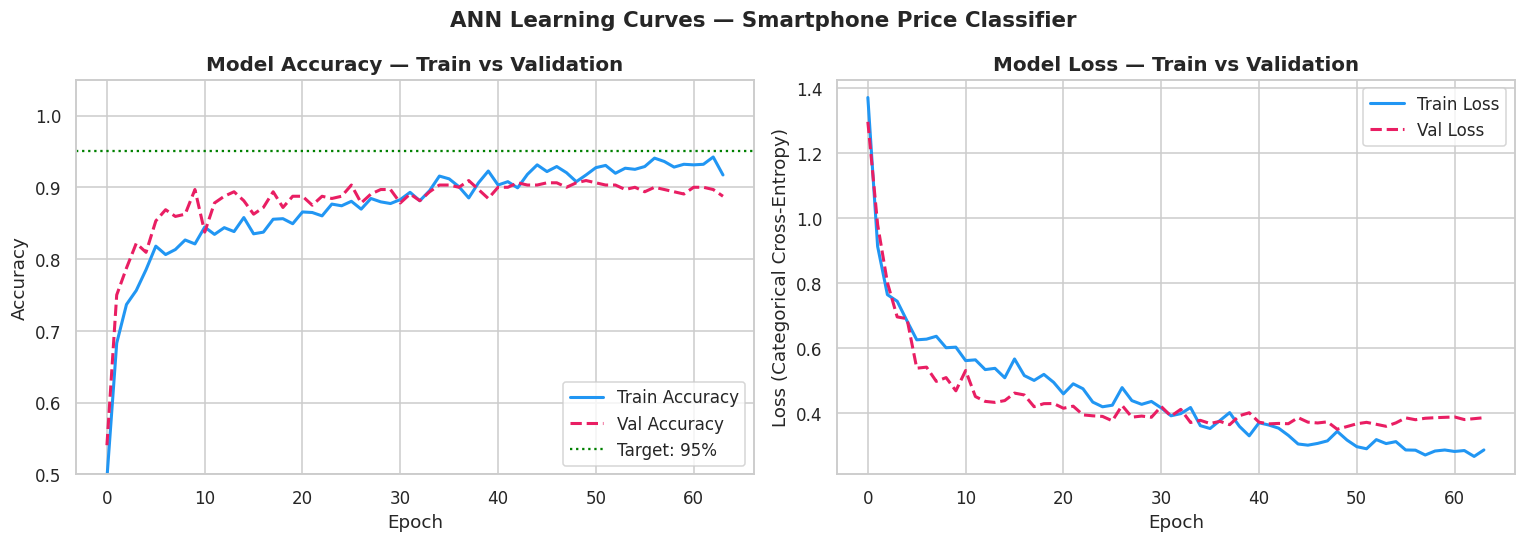

Final Train Accuracy : 91.72%
Final Val   Accuracy : 88.75%
Accuracy Gap         : 2.97%
→ GOOD FIT: Small gap between train and validation


In [63]:
# LEARNING CURVES
# Purpose: Visual diagnostic to check for:
#   - Overfitting  → train acc high, val acc low (gap between lines)
#   - Underfitting → both acc values low (model too simple)
#   - Good fit     → both lines converge and stay close

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(history.history['accuracy'],     label='Train Accuracy',
             color='#2196F3', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',
             color='#E91E63', linewidth=2, linestyle='--')
axes[0].axhline(y=0.95, color='green', linestyle=':', linewidth=1.5,
                label='Target: 95%')
axes[0].set_title('Model Accuracy — Train vs Validation')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].set_ylim([0.5, 1.05])

# Loss plot
axes[1].plot(history.history['loss'],     label='Train Loss',
             color='#2196F3', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val Loss',
             color='#E91E63', linewidth=2, linestyle='--')
axes[1].set_title('Model Loss — Train vs Validation')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss (Categorical Cross-Entropy)')
axes[1].legend()

plt.suptitle('ANN Learning Curves — Smartphone Price Classifier',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Diagnose overfitting
final_train_acc = history.history['accuracy'][-1]
final_val_acc   = history.history['val_accuracy'][-1]
gap = final_train_acc - final_val_acc
print(f'Final Train Accuracy : {final_train_acc*100:.2f}%')
print(f'Final Val   Accuracy : {final_val_acc*100:.2f}%')
print(f'Accuracy Gap         : {gap*100:.2f}%')
if gap < 0.05:
    print('→ GOOD FIT: Small gap between train and validation')
elif gap < 0.10:
    print('→ MILD OVERFIT: Acceptable — model is generalizing reasonably')
else:
    print('→ OVERFIT WARNING: Consider more Dropout or more data')


#Evaluation Metrics
Why multiple metrics?

Accuracy — overall % correct
Precision — of all predicted class X, how many were actually class X?

Recall — of all actual class X, how many did the model catch?

F1 Score — harmonic mean of Precision and Recall

In [65]:
# EVALUATE ON TEST SET
# model.evaluate() gives the compiled metrics (loss + accuracy)
# We then get raw class predictions for detailed sklearn metrics

test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)

# model.predict() returns 4 probabilities per sample (softmax output)
# np.argmax gives us the class with highest probability
y_pred_proba = model.predict(X_test, verbose=0)
y_pred       = np.argmax(y_pred_proba, axis=1)  # predicted class labels
y_true       = y_test.values                     # actual class labels

print('  FINAL TEST RESULTS')

print(f'  Test Loss     : {test_loss:.4f}')
print(f'  Test Accuracy : {test_acc*100:.2f}%')
print()

# PRD target check
target_acc = 0.95
if test_acc >= target_acc:
    print(f'  TARGET MET: Accuracy {test_acc*100:.2f}% >= {target_acc*100}%')
else:
    print(f'   target ({target_acc*100}%) not yet met — {test_acc*100:.2f}% achieved')

print()


# CLASSIFICATION REPORT
# Shows per-class Precision, Recall, F1-Score, and Support
# 'macro avg' = unweighted mean across classes
# 'weighted avg' = weighted by class size (same as overall accuracy here
#                  since dataset is balanced)

class_names = ['Budget (0)', 'Low-Mid (1)', 'Mid-High (2)', 'Premium (3)']
print('CLASSIFICATION REPORT:')
print('─' * 60)
print(classification_report(y_true, y_pred, target_names=class_names))


  FINAL TEST RESULTS
  Test Loss     : 0.3073
  Test Accuracy : 92.50%

   target (95.0%) not yet met — 92.50% achieved

CLASSIFICATION REPORT:
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

  Budget (0)       0.94      0.97      0.96       100
 Low-Mid (1)       0.91      0.89      0.90       100
Mid-High (2)       0.90      0.89      0.89       100
 Premium (3)       0.95      0.95      0.95       100

    accuracy                           0.93       400
   macro avg       0.92      0.93      0.92       400
weighted avg       0.92      0.93      0.92       400



#Confusion Matrix
The diagonal of the confusion matrix represents correct predictions. Off-diagonal values show where the model confuses one class for another. Budget vs Low-Mid confusion is acceptable; Budget vs Premium confusion would be a serious error.

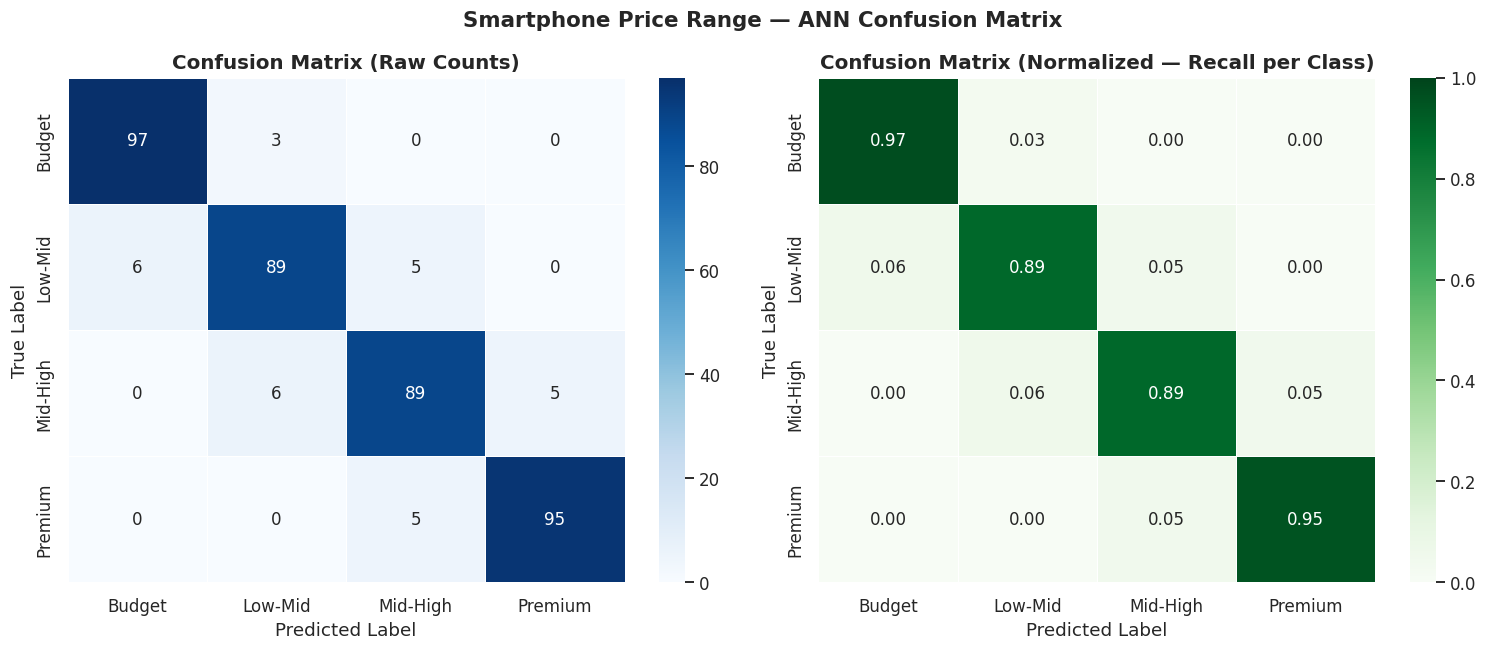

Per-class Accuracy (diagonal of normalized matrix):
  Budget    : 97.0% correctly classified
  Low-Mid   : 89.0% correctly classified
  Mid-High  : 89.0% correctly classified
  Premium   : 95.0% correctly classified

Most common misclassification:
  Actual Low-Mid → Predicted Budget : 6 samples
  (Adjacent class confusion is expected and acceptable)


In [72]:
# CONFUSION MATRIX
# Rows = Actual class, Columns = Predicted class
# Diagonal = correctly classified samples
# Off-diagonal = misclassifications

cm      = confusion_matrix(y_true, y_pred)
cm_norm = confusion_matrix(y_true, y_pred, normalize='true')  # row-normalized

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
short_names = ['Budget', 'Low-Mid', 'Mid-High', 'Premium']

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=short_names, yticklabels=short_names,
            linewidths=0.5, ax=axes[0])
axes[0].set_title('Confusion Matrix (Raw Counts)')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# Normalized
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=short_names, yticklabels=short_names,
            linewidths=0.5, ax=axes[1], vmin=0, vmax=1)
axes[1].set_title('Confusion Matrix (Normalized — Recall per Class)')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.suptitle('Smartphone Price Range — ANN Confusion Matrix',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# # Interpret confusion matrix
print('Per-class Accuracy (diagonal of normalized matrix):')
for i, name in enumerate(short_names):
    print(f'  {name:<10}: {cm_norm[i,i]*100:.1f}% correctly classified')
print()
print('Most common misclassification:')
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)
r, c = np.unravel_index(np.argmax(cm_no_diag), cm_no_diag.shape)
print(f'  Actual {short_names[r]} → Predicted {short_names[c]} : {cm_no_diag[r,c]} samples')
print('  (Adjacent class confusion is expected and acceptable)')


#Confidence Score Analysis

Confidence Score Distribution:
  Mean confidence   : 91.9%
  Min  confidence   : 50.8%
  Max  confidence   : 100.0%
  Samples > 90% conf: 297 / 400
  Samples > 80% conf: 336 / 400



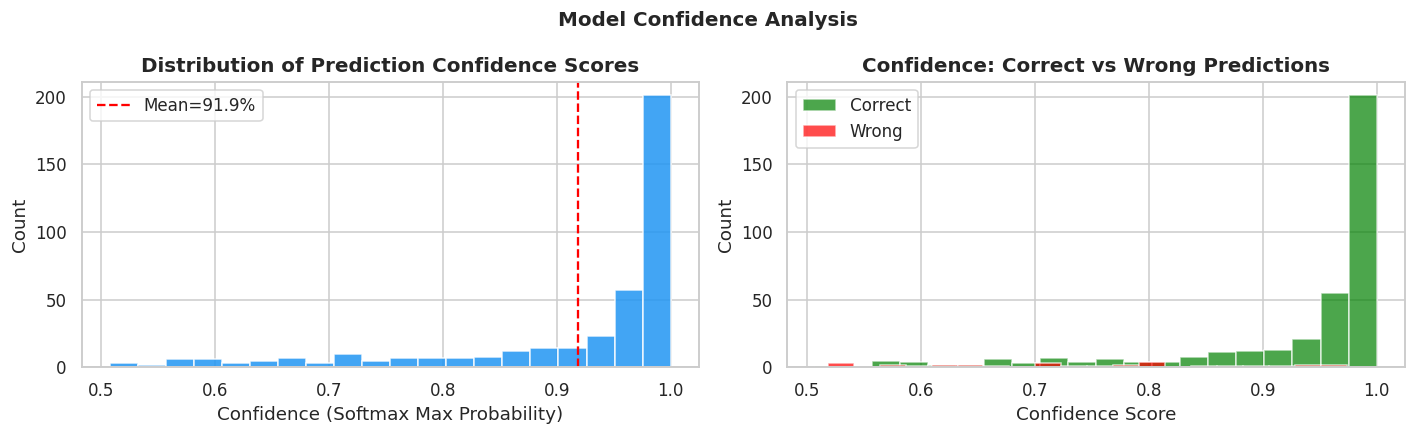

In [74]:
# CONFIDENCE SCORE ANALYSIS
# y_pred_proba shape: (n_samples, 4) — 4 class probabilities per sample
# max_confidence = the highest probability = what we show as 'X% confident'
#
# This answers the PRD requirement: 'Visual: Confidence Score (e.g., 92% confident)'

max_confidence = y_pred_proba.max(axis=1)  # confidence for each prediction

print('Confidence Score Distribution:')
print(f'  Mean confidence   : {max_confidence.mean()*100:.1f}%')
print(f'  Min  confidence   : {max_confidence.min()*100:.1f}%')
print(f'  Max  confidence   : {max_confidence.max()*100:.1f}%')
print(f'  Samples > 90% conf: {(max_confidence > 0.90).sum()} / {len(max_confidence)}')
print(f'  Samples > 80% conf: {(max_confidence > 0.80).sum()} / {len(max_confidence)}')
print()

# Confidence histogram
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(max_confidence, bins=20, color='#2196F3', edgecolor='white', alpha=0.85)
axes[0].axvline(max_confidence.mean(), color='red', linestyle='--',
                label=f'Mean={max_confidence.mean()*100:.1f}%')
axes[0].set_title('Distribution of Prediction Confidence Scores')
axes[0].set_xlabel('Confidence (Softmax Max Probability)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Confidence vs correct/wrong
correct_mask = (y_pred == y_true)
axes[1].hist(max_confidence[correct_mask],  bins=20, alpha=0.7,
             color='green', label='Correct', edgecolor='white')
axes[1].hist(max_confidence[~correct_mask], bins=20, alpha=0.7,
             color='red',   label='Wrong',   edgecolor='white')
axes[1].set_title('Confidence: Correct vs Wrong Predictions')
axes[1].set_xlabel('Confidence Score')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.suptitle('Model Confidence Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


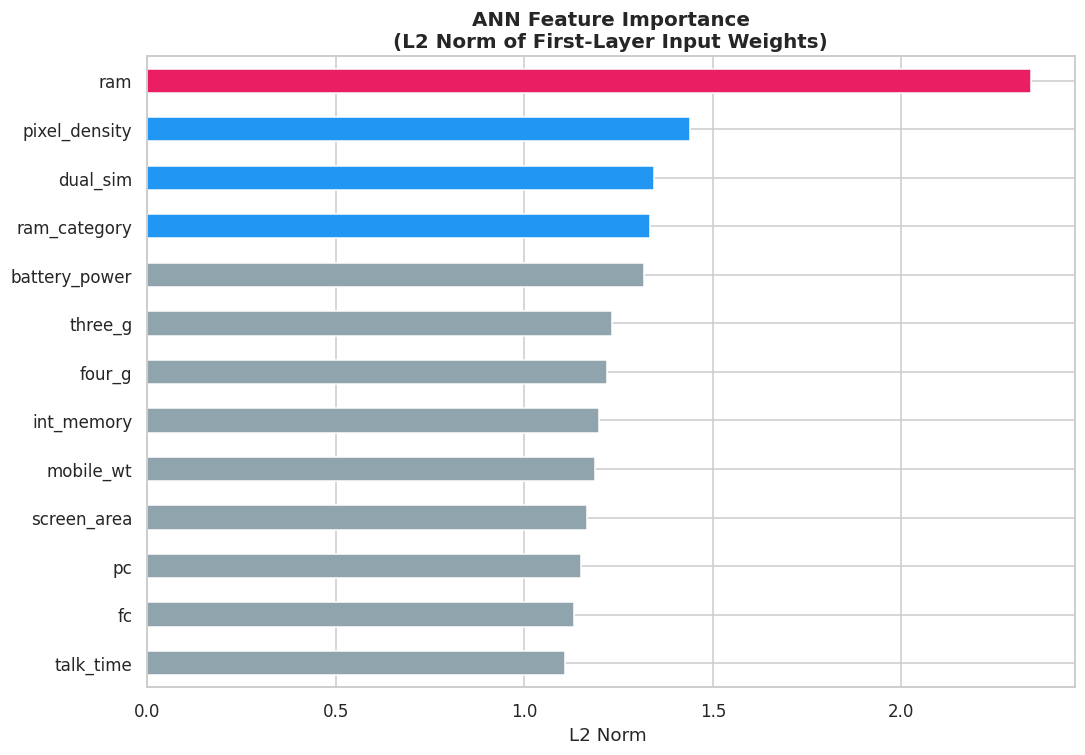

Top 5 most important features (by first-layer weight norm):
  ram                     : 2.3420
  pixel_density           : 1.4391
  dual_sim                : 1.3435
  ram_category            : 1.3341
  battery_power           : 1.3163



In [76]:
# ANN FEATURE IMPORTANCE (Weight-based)

# For ANNs, true feature importance is harder to compute than in tree models.
# A common proxy: take the L2 norm of the weights from each input neuron
# to the first hidden layer. Larger norms = more influence on first layer.


first_layer_weights = model.layers[0].get_weights()[0]  # shape: (n_features, 256)
feature_importance  = np.linalg.norm(first_layer_weights, axis=1)
feature_names       = list(X_train.columns)

# Sort by importance
imp_series = pd.Series(feature_importance, index=feature_names).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#E91E63' if v == imp_series.max() else
          '#2196F3' if v >= imp_series.quantile(0.75) else
          '#90A4AE' for v in imp_series.sort_values().values]
imp_series.sort_values().plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title('ANN Feature Importance\n(L2 Norm of First-Layer Input Weights)',
             fontweight='bold')
ax.set_xlabel('L2 Norm ')

plt.tight_layout()
plt.show()

print('Top 5 most important features (by first-layer weight norm):')
for feat, val in imp_series.head(5).items():
    print(f'  {feat:<24}: {val:.4f}')
print()



In [ ]:
from sklearn.metrics import f1_score, precision_score, recall_score

f1        = f1_score(y_true, y_pred, average='weighted')
precision = precision_score(y_true, y_pred, average='weighted')
recall    = recall_score(y_true, y_pred, average='weighted')

print(f'  Test Accuracy  : {test_acc*100:.2f}%')
print(f'  Precision      : {precision*100:.2f}%')
print(f'  Recall         : {recall*100:.2f}%')
print(f'  F1 Score       : {f1*100:.2f}%')
print(f'  Avg Confidence : {max_confidence.mean()*100:.1f}%')



  Test Accuracy  : 92.75%
  Precision      : 92.75%
  Recall         : 92.75%
  F1 Score       : 92.73%
  Avg Confidence : 91.9%
